# File Breakdown

If you would like to best understand this file especially code block outputs, please navigate it alongside the appropriate documentation via the PC: Data Documentation google docs file. Otherwise you can do without it only reading the comments and ignoring the notes, but if you do not understand an output or are beginning to feel confused please refer to the documentation afterall that's what it's there for.


Navigate to the correct section of the google docs file by:
- Opening the panel on the left
- Clicking on Kayden
- Clicking on WorldBankForecasting (under Forecasting)

There will be notes in the comments for when to refer to the documentation for further clarity. Notes in all caps are changes I may need to make

Hopefully I cooked with this lol

### Executive Summary:
Step 1: Data Loading (Read in dataset, Import packages, etc.)

Step 2: Exploratory Data Analysis (Identify null values, Plot random countries to gauge trends we’re working with)

Step 3: Data Preprocessing (Get rid of null values, Get rid of null countries / years where no data was collected)

Step 4: Model Building (Holt-Winters, ARIMA)

Step 5: Model Evaluation (Use MAE, RMSE, MAPE (for interpretability?, Create confidence intervals?)

Step 6: Conclusion

# Step 1: Data Loading

In [ ]:
# Import packages and warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", message="Non-stationary starting autoregressive parameters")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.simplefilter('ignore', ConvergenceWarning)

In [377]:
# Read in the dataset and preview the first 5 rows
df = pd.read_csv('C:/Users/kayde/OneDrive/Documents/GitHub/PC-Data-Dash/data/interim/world_bank_interim.csv')
df.head()

,country,iso3,indicator-code,indicator,year,value
0,Afghanistan,AFG,EN.POP.DNST,Population density (people per sq. km of land ...,2010,43.365207
1,Afghanistan,AFG,EN.POP.DNST,Population density (people per sq. km of land ...,2011,44.995949
2,Afghanistan,AFG,EN.POP.DNST,Population density (people per sq. km of land ...,2012,46.854689
3,Afghanistan,AFG,EN.POP.DNST,Population density (people per sq. km of land ...,2013,48.483977
4,Afghanistan,AFG,EN.POP.DNST,Population density (people per sq. km of land ...,2014,50.277545


# Step 2: Exploratory Data Analysis

In [ ]:
# Identifies how many rows and columns in dataset, if there are any null entries in each column and dataset memory size 
df.info()
# Prints number of null entries per column
# See Note 2.1 in documentation
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3990 entries, 0 to 3989
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         3990 non-null   object 
 1   iso3            3915 non-null   object 
 2   indicator-code  3990 non-null   object 
 3   indicator       3990 non-null   object 
 4   year            3990 non-null   int64  
 5   value           3639 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 187.2+ KB


country             0
iso3               75
indicator-code      0
indicator           0
year                0
value             351
dtype: int64

In [364]:
# Statistical breakdown of numerical data
df.describe()

,year,value
count,3990.000000,3639.000000
mean,2017.000000,372.967765
std,4.321035,1798.081915
min,2010.000000,0.136492
25%,2013.000000,36.764798
50%,2017.000000,79.422792
75%,2021.000000,196.882478
max,2024.000000,21393.442620


In [ ]:
# Print the rows with no score values provided
# See Note 2.2 in documentation
null_rows = df[df['value'].isnull()]
print(null_rows)

                          country iso3 indicator-code  \
14                    Afghanistan  AFG    EN.POP.DNST   
28    Africa Eastern and Southern  AFE    EN.POP.DNST   
29    Africa Eastern and Southern  AFE    EN.POP.DNST   
43     Africa Western and Central  AFW    EN.POP.DNST   
44     Africa Western and Central  AFW    EN.POP.DNST   
...                           ...  ...            ...   
3943                        World  WLD    EN.POP.DNST   
3944                        World  WLD    EN.POP.DNST   
3959                  Yemen, Rep.  YEM    EN.POP.DNST   
3974                       Zambia  ZMB    EN.POP.DNST   
3989                     Zimbabwe  ZWE    EN.POP.DNST   

                                              indicator  year  value  
14    Population density (people per sq. km of land ...  2024    NaN  
28    Population density (people per sq. km of land ...  2023    NaN  
29    Population density (people per sq. km of land ...  2024    NaN  
43    Population density (peopl

In [ ]:
# See Note 2.3 in documentation
for col in null_rows:
    null_breakdown = df[df['value'].isnull()][col].value_counts()
    print(null_breakdown)

country
Not classified          15
Kosovo                  15
Sudan                    3
South Sudan              3
Channel Islands          3
                        ..
Guyana                   1
Haiti                    1
Honduras                 1
Hong Kong SAR, China     1
Zimbabwe                 1
Name: count, Length: 266, dtype: int64
iso3
XKX    15
SDN     3
SSD     3
CHI     3
LTE     2
       ..
GNB     1
GUY     1
HTI     1
HND     1
ZWE     1
Name: count, Length: 261, dtype: int64
indicator-code
EN.POP.DNST    351
Name: count, dtype: int64
indicator
Population density (people per sq. km of land area)    351
Name: count, dtype: int64
year
2024    266
2023     51
2010      7
2011      4
2022      3
2012      2
2013      2
2014      2
2015      2
2016      2
2017      2
2018      2
2019      2
2020      2
2021      2
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [384]:
# Prints the number of years with null scores excluding 2024 for each country
select_null_rows = (df[(df['year'] != 2024) & (df['value'].isnull())])
print(select_null_rows['country'].value_counts())
print((select_null_rows['country'].value_counts()).count())

country
Kosovo                                                                       14
Not classified                                                               14
Sudan                                                                         2
Channel Islands                                                               2
South Sudan                                                                   2
Africa Eastern and Southern                                                   1
Pacific island small states                                                   1
Low income                                                                    1
Lower middle income                                                           1
Middle East, North Africa, Afghanistan & Pakistan                             1
Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)                1
Middle East, North Africa, Afghanistan & Pakistan (excluding high income)     1
Middle income                   

In [ ]:
# Create a list of countries that have null scores that aren't in 2024 (used because the rest of these are not countries which will be purged later)
exceptioncountries = ['Curacao', 'St. Martin (French part)', 'Sint Maarten (Dutch part)', 'South Sudan', 'Channel Islands', 'Sudan', 'World']

Note: Drop rows with 2024 data, drop Kosovo (iso XKS) because all 15 years are dataless.

In [368]:
# THIS NEEDS TO BE TWEAKED BECAUSE OUTLIER CALCULATIONS ARE FOR 2010 INSTEAD OF THE MOST RECENT YEAR
# Outlier Identification (So we know who's being affected the most by the given variable)
# Print the lower bound, median and upper bound of the scores and the country outliers
outliers = []
visited_countries = []
Q1 = df['value'].quantile(0.25)
Q2 = df['value'].quantile(0.50)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
for index, row in df.iterrows():
    if row['country'] in visited_countries:
        continue 
    if (row['value'] < lower_bound) | (row['value'] > upper_bound):
        outliers.append({
            'country': row.country,
            'value': row.value
        })
        visited_countries.append(row['country'])

df_outliers = pd.DataFrame(outliers)
print(lower_bound, Q2, upper_bound)
print(df_outliers)

-203.4117224625 79.42279184 437.0589981175
                      country         value
0                       Aruba    565.766667
1                     Bahrain   1612.261155
2                  Bangladesh   1169.255443
3                    Barbados    640.100000
4                     Bermuda   1180.092593
5                     Burundi    437.673325
6             Channel Islands    801.116162
7                     Comoros    439.642128
8                   Gibraltar   3124.800000
9        Hong Kong SAR, China   6689.714286
10                      India    441.370108
11                     Israel    441.658965
12                Korea, Rep.    509.815967
13                    Lebanon    492.794526
14           Macao SAR, China  18080.808080
15                   Maldives   1202.640000
16                      Malta   1295.337500
17                  Mauritius    615.960591
18                     Monaco  16360.631480
19                      Nauru    502.150000
20                Netherlands    

In [ ]:
# THIS MAY BE COMPLETELY IRRELEVANT LETS SEE
# Prints how many years outlier countries have been outliers for ()
outliers = []
visited_countries = []
Q1 = df['value'].quantile(0.25)
Q2 = df['value'].quantile(0.50)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
for index, row in df.iterrows():
    if (row['value'] < lower_bound) | (row['value'] > upper_bound):
        outliers.append({
            'country' : row.country,
            'year' : row.year,
            'value': row.value
        })
        visited_countries.append(row['country'])

df_outliers = pd.DataFrame(outliers)
print(df_outliers['country'].value_counts())

country
Aruba                        14
Korea, Rep.                  14
Singapore                    14
San Marino                   14
Netherlands                  14
Nauru                        14
Monaco                       14
Mauritius                    14
Malta                        14
Maldives                     14
Bahrain                      14
Lebanon                      14
Macao SAR, China             14
Hong Kong SAR, China         14
Gibraltar                    14
Bermuda                      14
Barbados                     14
Bangladesh                   14
West Bank and Gaza           14
Sint Maarten (Dutch part)    13
St. Martin (French part)     13
Channel Islands              12
Rwanda                       12
South Asia                   12
South Asia (IDA & IBRD)      12
India                        10
Burundi                       8
Comoros                       3
Israel                        2
Name: count, dtype: int64


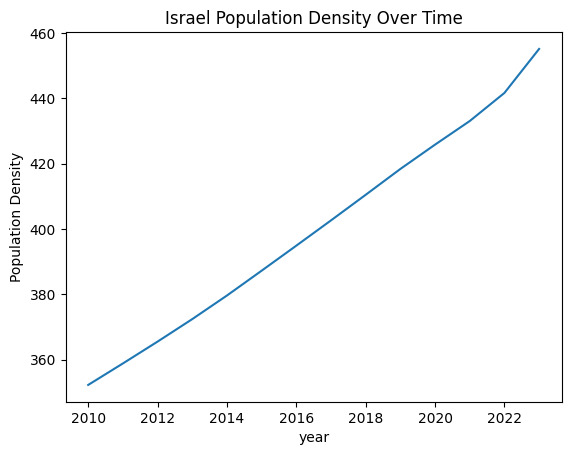

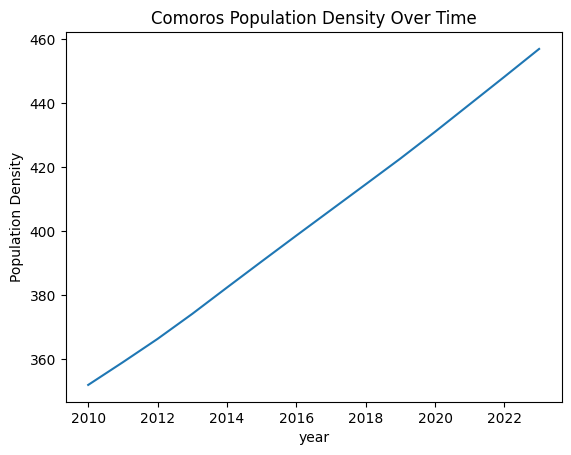

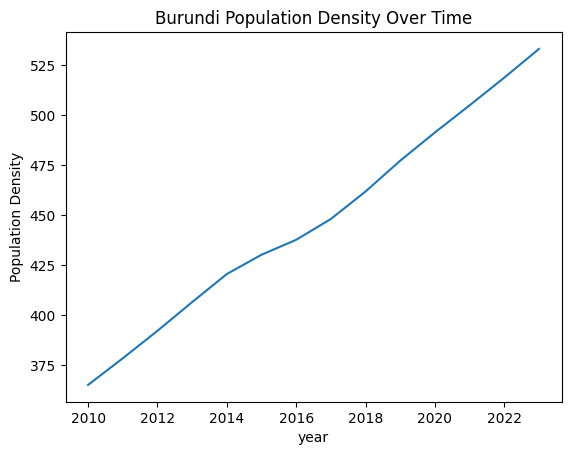

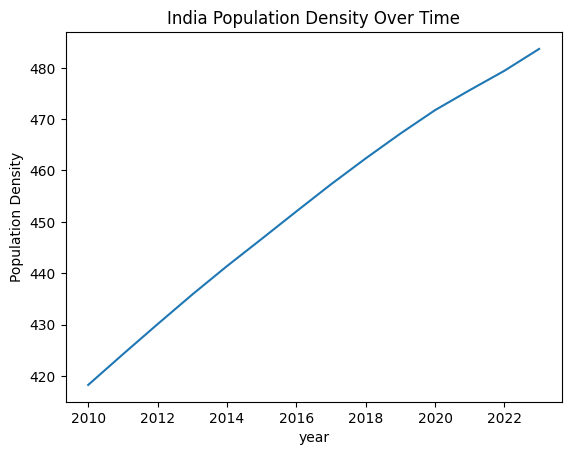

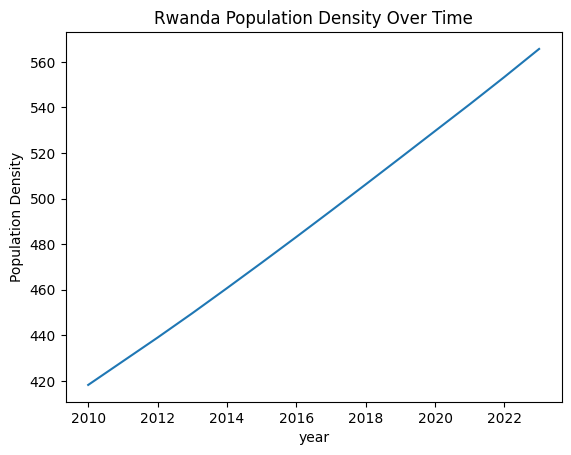

In [ ]:
# THIS MAY ALSO BE IRRELEVANT
# Visualize population density graphs for countries that weren't an outlier for all years in case they dropped off
country = ['Israel', 'Comoros', 'Burundi', 'India', 'Rwanda']
for i in country:
    sns.lineplot(data=df[df['country'] == i], x='year', y='value')
    plt.ylabel('Population Density')
    plt.title(f"{i} Population Density Over Time")
    plt.show()

# Step 3: Data Preprocessing

In [ ]:
# Drop null rows
# Drop non country rows
# See Note 3.1 in documentation
df = df.drop(columns=["indicator"])
for index, row in df.iterrows():
    if (row['year'] == 2024) or (row['country'] in select_null_rows['country'].values and row['country'] not in exceptioncountries):
        df = df.drop(index)


In [389]:
# Look at our new cleaned dataframe
# See Note 3.2 in documentation
df.describe()

,year,value
count,3038.000000,3028.000000
mean,2016.500000,432.820992
std,4.031792,1965.398515
min,2010.000000,0.136492
25%,2013.000000,36.899850
50%,2016.500000,89.956096
75%,2020.000000,225.896694
max,2023.000000,21393.442620


In [ ]:
# See what the new dataframe is looking like
df.head()

,country,iso3,indicator-code,year,value
0,Afghanistan,AFG,EN.POP.DNST,2010,43.365207
1,Afghanistan,AFG,EN.POP.DNST,2011,44.995949
2,Afghanistan,AFG,EN.POP.DNST,2012,46.854689
3,Afghanistan,AFG,EN.POP.DNST,2013,48.483977
4,Afghanistan,AFG,EN.POP.DNST,2014,50.277545


# Step 4: Model Building

1. Fit versions of Holt-Winters model
2. Fit versions of ARIMA model (probably just to ensure Holt-Winters is on the right track)

## 4.1: Naive model

In [ ]:
# MIGHT NEED TO INDICATE WHICH YEAR IS BEING PREDICTED / ENSURE ALL PREDICTIONS ARE FOR THE SAME YEAR
# Naive model (predicting next year by copying this year)
results_list_naive = []
for country in df["country"].unique():    
    df_subset = df[df["country"] == country].sort_values("year").dropna(subset=["value"])

    y = df_subset["value"]

    predicted = y.iloc[-2]
    actual = y.iloc[-1]
    
    error = actual - predicted
    absolute_error = abs(error)
    percent_error = (absolute_error / actual) * 100

    output_row = {
        "country": country,
        "forecast": predicted,
        "actual": actual,
        "percent_error": percent_error
    }
    
    results_list_naive.append(output_row)

final_df = pd.DataFrame(results_list_naive)
display(final_df)
print(final_df['percent_error'].median())


,country,forecast,actual,percent_error
0,Afghanistan,62.215541,63.558501,2.112952
1,Albania,89.475766,88.105657,1.555076
2,Algeria,19.094187,19.382560,1.487797
3,American Samoa,241.710000,237.605000,1.727657
4,Andorra,169.585106,172.034043,1.423518
...,...,...,...,...
212,West Bank and Gaza,837.114025,857.390042,2.364853
213,World,61.028876,61.591254,0.913081
214,"Yemen, Rep.",72.395924,74.608025,2.964964
215,Zambia,27.109509,27.877648,2.755395


1.1496728182519123


## 4.2: Holt-Winters Model

In [404]:
# MIGHT NEED TO INDICATE WHICH YEAR IS BEING PREDICTED / ENSURE ALL PREDICTIONS ARE FOR THE SAME YEAR
# Holt-Winters Model
results_list = []
for country in df["country"].unique():    
    df_subset = df[df["country"] == country].sort_values("year").dropna(subset=["value"])

    y = df_subset["value"]
    y.index = pd.PeriodIndex(df_subset["year"], freq="Y")
    y_train = y.iloc[:-1]
    y_test = y.iloc[-1]

    fit = ExponentialSmoothing(
        y_train, trend="add", seasonal=None, initialization_method="estimated"
    ).fit()

    forecast = fit.forecast(1)
    
    predicted = forecast.iloc[0]
    actual = y_test
    
    error = actual - predicted
    absolute_error = abs(error)
    percent_error = (absolute_error / actual) * 100

    output_row = {
        "country": country,
        "forecast": predicted,
        "actual": actual,
        "percent_error": percent_error
    }
    
    results_list.append(output_row)

final_df = pd.DataFrame(results_list)
display(final_df)
print(final_df['percent_error'].median())


,country,forecast,actual,percent_error
0,Afghanistan,64.375461,63.558501,1.285367
1,Albania,87.915971,88.105657,0.215293
2,Algeria,19.419200,19.382560,0.189037
3,American Samoa,238.840834,237.605000,0.520121
4,Andorra,172.438298,172.034043,0.234986
...,...,...,...,...
212,West Bank and Gaza,856.950598,857.390042,0.051254
213,World,61.497480,61.591254,0.152253
214,"Yemen, Rep.",74.446506,74.608025,0.216490
215,Zambia,27.848463,27.877648,0.104690


0.15999101015454928


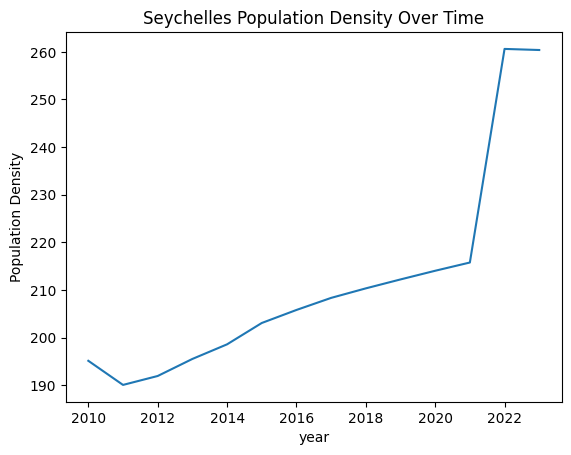

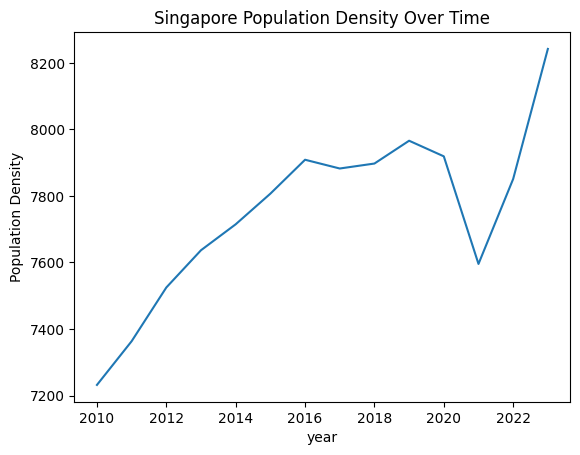

In [406]:
country = ['Seychelles', 'Singapore']
for i in country:
    sns.lineplot(data=df[df['country'] == i], x='year', y='value')
    plt.ylabel('Population Density')
    plt.title(f"{i} Population Density Over Time")
    plt.show()

Bruh.

# 4.2: ARIMA model

In [413]:
# MIGHT NEED TO INDICATE WHICH YEAR IS BEING PREDICTED / ENSURE ALL PREDICTIONS ARE FOR THE SAME YEAR
# ARIMA Model
results_list = []
for country in df["country"].unique():    
    df_subset = df[df["country"] == country].sort_values("year").dropna(subset=["value"])

    y = df_subset["value"]
    y.index = pd.PeriodIndex(df_subset["year"], freq="Y")
    y_train = y.iloc[:-1]
    y_test = y.iloc[-1]

    arima_model = ARIMA(y_train, order=(1, 1, 0)).fit()
    forecast = arima_model.forecast(steps=1).iloc[0]
    
    predicted = forecast
    actual = y_test
    
    error = actual - predicted
    absolute_error = abs(error)
    percent_error = (absolute_error / actual) * 100

    output_row = {
        "country": country,
        "forecast": predicted,
        "actual": actual,
        "percent_error": percent_error
    }
    
    results_list.append(output_row)

final_df = pd.DataFrame(results_list)
display(final_df)
print(final_df['percent_error'].median())


,country,forecast,actual,percent_error
0,Afghanistan,63.085399,63.558501,0.744356
1,Albania,88.160964,88.105657,0.062774
2,Algeria,19.394818,19.382560,0.063241
3,American Samoa,237.395254,237.605000,0.088275
4,Andorra,172.022278,172.034043,0.006838
...,...,...,...,...
212,West Bank and Gaza,857.110597,857.390042,0.032592
213,World,61.445806,61.591254,0.236151
214,"Yemen, Rep.",74.445275,74.608025,0.218140
215,Zambia,27.848036,27.877648,0.106222


0.10622229634159588


In [433]:
# Compiled combined version, works best for the python file
test_list = []

for country in df["country"].unique():    
    # 1. Filter and Clean
    df_subset = df[df["country"] == country].sort_values("year").dropna(subset=["value"])
    
    # Safety Check
    if len(df_subset) < 5: # ARIMA and HW like a bit more data
        continue

    # 2. IMPORTANT: Re-define your target variables for THIS country
    y = df_subset["value"]
    y.index = pd.PeriodIndex(df_subset["year"], freq="Y")
    y_train = y.iloc[:-1]
    y_test = y.iloc[-1]
    actual = y_test

    # --- MODEL 1: Naive ---
    naive_forecast = y_train.iloc[-1]
    naive_per_error = (abs(actual - naive_forecast) / actual) * 100

    # --- MODEL 2: Holt-Winters (HW) ---
    hw_fit = ExponentialSmoothing(
        y_train, trend="add", seasonal=None, initialization_method="estimated"
    ).fit()
    hw_forecast = hw_fit.forecast(1).iloc[0]
    hw_per_error = (abs(actual - hw_forecast) / actual) * 100

    # --- MODEL 3: ARIMA ---
    arima_model = ARIMA(y_train, order=(1, 1, 0)).fit()
    arima_forecast = arima_model.forecast(steps=1).iloc[0]
    arima_per_error = (abs(actual - arima_forecast) / actual) * 100

    # 3. Store results
    output_row = {
        "country": country,
        "actual": actual,
        "Naive_error": naive_per_error,
        "HW_error": hw_per_error,
        "ARIMA_error": arima_per_error
    }
    
    # MUST BE INDENTED to be inside the loop
    test_list.append(output_row)

# Combine and Display
final_df = pd.DataFrame(test_list)
display(final_df)

,country,actual,Naive_error,HW_error,ARIMA_error
0,Afghanistan,63.558501,2.112952,1.285367,0.744356
1,Albania,88.105657,1.555076,0.215293,0.062774
2,Algeria,19.382560,1.487797,0.189037,0.063241
3,American Samoa,237.605000,1.727657,0.520121,0.088275
4,Andorra,172.034043,1.423518,0.234986,0.006838
...,...,...,...,...,...
212,West Bank and Gaza,857.390042,2.364853,0.051254,0.032592
213,World,61.591254,0.913081,0.152253,0.236151
214,"Yemen, Rep.",74.608025,2.964964,0.216490,0.218140
215,Zambia,27.877648,2.755395,0.104690,0.106222


In [434]:
print(f"Median HW error {final_df['HW_error'].median()}")
print(f"Median Naive error {final_df['Naive_error'].median()}")
print(f"Median ARIMA error {final_df['ARIMA_error'].median()}")


Median HW error 0.15999101015454928
Median Naive error 1.1496728182519123
Median ARIMA error 0.10622229634159588


In [435]:
# SET 2% THRESHOLD?
# Mapping Outliers for both Models
Q1_hw = final_df['HW_error'].quantile(0.25)
Q3_hw = final_df['HW_error'].quantile(0.75)
IQR_hw = Q3_hw - Q1_hw
upper_hw = Q3_hw + 1.5 * IQR_hw

# 2. Define outliers for ARIMA
Q1_ar = final_df['ARIMA_error'].quantile(0.25)
Q3_ar = final_df['ARIMA_error'].quantile(0.75)
IQR_ar = Q3_ar - Q1_ar
upper_ar = Q3_ar + 1.5 * IQR_ar

# 3. Create a Filter: Is it an outlier in HW OR ARIMA?
is_outlier = (final_df['HW_error'] > upper_hw) | (final_df['ARIMA_error'] > upper_ar)

# 4. Create the final clean report
outlier_report = final_df[is_outlier][['country', 'HW_error', 'ARIMA_error']].copy()

# Sort by the highest error to show the "biggest failures" first
outlier_report = outlier_report.sort_values(by=['ARIMA_error', 'HW_error'], ascending=False)
print(f"HW threshold {upper_hw}")
print(f"ARIMA threshold {upper_ar}")
display(outlier_report)

HW threshold 1.1675431334667956
ARIMA threshold 0.7042381684068588


,country,HW_error,ARIMA_error
168,Seychelles,10.018277,8.130198
170,Singapore,6.372104,4.573884
177,South Sudan,3.794210,3.264643
86,"Hong Kong SAR, China",3.410252,3.245663
165,Saudi Arabia,2.540713,3.073183
52,Czechia,1.767253,2.780714
140,New Zealand,1.103526,2.322705
147,Oman,1.767405,2.318117
202,Ukraine,0.175063,2.302571
188,Syrian Arab Republic,1.267730,2.029381


# Step 5: Model Implementation

In [444]:
# Compiled combined version, works best for the python file
test_list = []

for country in df["country"].unique():    
    # 1. Filter and Clean
    df_subset = df[df["country"] == country].sort_values("year").dropna(subset=["value"])
    
    # Safety Check
    if len(df_subset) < 5: # ARIMA and HW like a bit more data
        continue

    # 2. IMPORTANT: Re-define your target variables for THIS country
    y = df_subset["value"]
    y.index = pd.PeriodIndex(df_subset["year"], freq="Y")
    y_train = y.iloc[:]

    # --- MODEL 2: Holt-Winters (HW) ---
    hw_fit = ExponentialSmoothing(
        y_train, trend="add", seasonal=None, initialization_method="estimated"
    ).fit()
    hw_forecast = hw_fit.forecast(1).iloc[0]

    # --- MODEL 3: ARIMA ---
    arima_model = ARIMA(y_train, order=(1, 1, 0)).fit()
    arima_forecast = arima_model.forecast(steps=1).iloc[0]

    # 3. Store results
    output_row = {
        "country": country,
        "HW_Prediction": hw_forecast,
        "ARIMA_Prediction": arima_forecast,
        "Weighted_Prediction": (hw_forecast + arima_forecast) / 2
    }
    
    # MUST BE INDENTED to be inside the loop
    test_list.append(output_row)

# Combine and Display
final_df = pd.DataFrame(test_list)
display(final_df)

,country,HW_Prediction,ARIMA_Prediction,Weighted_Prediction
0,Afghanistan,65.111831,64.876881,64.994356
1,Albania,86.498930,86.805912,86.652421
2,Algeria,19.670933,19.669991,19.670462
3,American Samoa,234.640769,233.594898,234.117833
4,Andorra,174.482979,174.140447,174.311713
...,...,...,...,...
212,West Bank and Gaza,877.579564,877.607733,877.593648
213,World,62.107356,62.005919,62.056638
214,"Yemen, Rep.",76.820126,76.818434,76.819280
215,Zambia,28.645788,28.645734,28.645761


In [ ]:
# SHOULD WE SCALE OR JUST DO BINARY CLASSIFICATION LIKE PLANCATALYST SUGGESTED (TO BE FAIR IT IS IMPACT)
# 1. Scale BOTH predictions in the original DF
predictions = ['HW', 'ARIMA', 'Weighted']

for i in predictions:
    # Notice we added "_Prediction" here to match your column names
    col_name = f'{i}_Prediction' 
    
    # Safety Check: Only scale if the column exists
    if col_name in final_df.columns:
        col = final_df[col_name]
        final_df[f'{i}_Prediction_scaled'] = (col - col.min()) / (col.max() - col.min()) * 100

# 2. Create the new DF
final_df_scaled = final_df[['country', 'HW_Prediction_scaled', 'ARIMA_Prediction_scaled', 'Weighted_Prediction_scaled']].copy()

display(final_df_scaled)

,country,HW_Prediction_scaled,ARIMA_Prediction_scaled,Weighted_Prediction_scaled
0,Afghanistan,0.312957,0.314605,0.313778
1,Albania,0.415973,0.421173,0.418561
2,Algeria,0.094081,0.094915,0.094496
3,American Samoa,1.129531,1.134516,1.132012
4,Andorra,0.839767,0.845588,0.842665
...,...,...,...,...
212,West Bank and Gaza,4.226388,4.264195,4.245208
213,World,0.298485,0.300653,0.299565
214,"Yemen, Rep.",0.369353,0.372637,0.370988
215,Zambia,0.137310,0.138534,0.137920


In [447]:
final_df_scaled.describe()

,HW_Prediction_scaled,ARIMA_Prediction_scaled,Weighted_Prediction_scaled
count,217.000000,217.000000,217.000000
mean,2.202409,2.219353,2.210844
std,9.826694,9.872740,9.849579
min,0.000000,0.000000,0.000000
25%,0.192517,0.194159,0.193303
50%,0.465125,0.469517,0.467311
75%,1.200401,1.211053,1.205703
max,100.000000,100.000000,100.000000


Convert finalized into .csv